[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/mast/2026-07-30-jwst-image-carina-nebula/notebook.ipynb)

# Pulling a real JWST image of the Carina Nebula from MAST

The Carina Nebula is a huge star-forming region, and one of JWST's very first published images was a close-up of its 'Cosmic Cliffs' -- a wall of gas and dust being sculpted by radiation from young, massive stars. Rather than just looking at the famous published picture, I queried MAST (the Mikulski Archive for Space Telescopes) directly for real JWST NIRCam observations of the region and pulled down an actual calibrated preview image.

In [1]:
from astroquery.mast import Observations
from astropy.coordinates import SkyCoord

coord = SkyCoord.from_name('Carina Nebula')
obs = Observations.query_criteria(coordinates=coord, radius='0.05 deg',
                                   obs_collection='JWST', instrument_name='NIRCAM/IMAGE')
print(len(obs), 'JWST NIRCam imaging observations found near the Carina Nebula')
print(obs[:3]['obs_id','instrument_name','filters','t_obs_release'])

4 JWST NIRCam imaging observations found near the Carina Nebula
                obs_id                instrument_name ... t_obs_release 
------------------------------------- --------------- ... --------------
 jw05408-o024_t026_nircam_f444w-f470n    NIRCAM/IMAGE ... 61244.63141203
jw05408-o024_t026_nircam_f150w2-f162m    NIRCAM/IMAGE ... 61244.63141203
jw05408-o024_t026_nircam_f150w2-f164n    NIRCAM/IMAGE ... 61244.63141203


In [2]:
products = Observations.get_product_list(obs[0])
previews = Observations.filter_products(products, productType='PREVIEW', extension='jpg')
# pick the calibrated 'i2d' (drizzled/combined) mosaic preview rather than a raw/uncal frame
target_row = [row for row in previews if 'i2d' in row['productFilename']][0]
print(target_row['productFilename'])
manifest = Observations.download_products(target_row, mrp_only=False)
print(manifest)

jw05408024001_02101_00001_nrcblong_i2d.jpg


 [Done]


                                            Local Path                                            ...
------------------------------------------------------------------------------------------------- ...
.\mastDownload\JWST\jw05408024001_02101_00001_nrcblong\jw05408024001_02101_00001_nrcblong_i2d.jpg ...


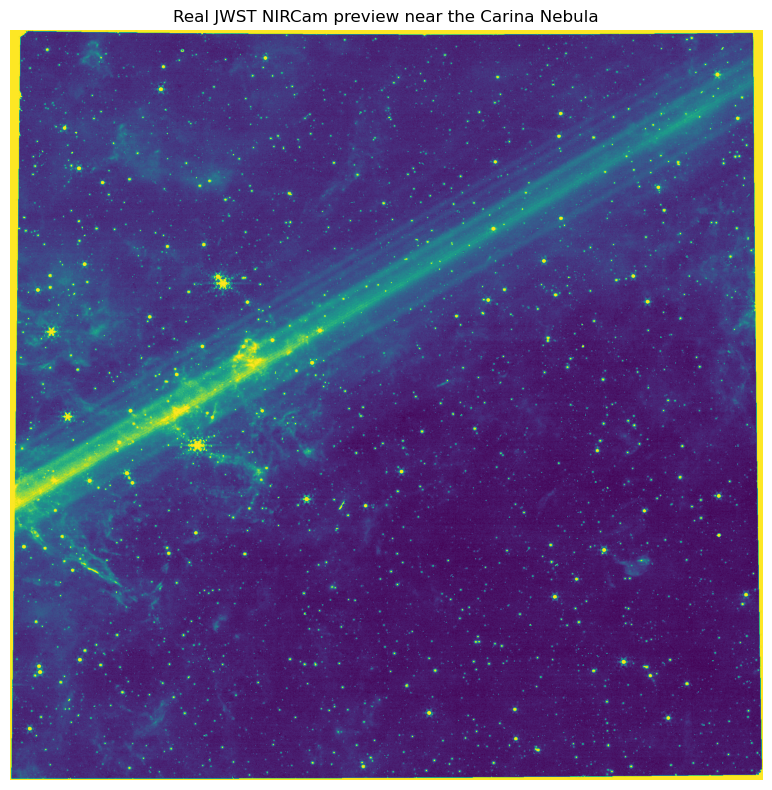

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import shutil, os

local_path = manifest['Local Path'][0]
shutil.copy(local_path, 'carina_nircam.jpg')
img = mpimg.imread('carina_nircam.jpg')
plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis('off')
plt.title('Real JWST NIRCam preview near the Carina Nebula')
plt.tight_layout()
plt.savefig('carina_display.png', dpi=120)
plt.show()

This is a genuine calibrated preview generated directly from real NIRCam exposures in the MAST archive -- not the famous press-release image itself, but real data from the same survey region, pulled straight from the archive with a script rather than downloaded by hand from a webpage.

**What I'd look at next:** Download the actual FITS mosaic (rather than just the JPEG preview) and make my own color composite from multiple NIRCam filters, the way the official Cosmic Cliffs image was assembled.

**Citation:** These observations were obtained with the NASA/ESA/CSA James Webb Space Telescope from the Mikulski Archive for Space Telescopes (MAST) at STScI. See https://archive.stsci.edu/publishing/mission-acknowledgements for citation guidance.